# Exploratory Data Analysis (EDA)

Project: AI-Powered Retail Demand Forecasting & Inventory Optimization

Objective:
- Understand sales patterns
- Analyze store performance
- Analyze seasonal trends
- Generate business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/retail_clean.csv")

In [4]:
print("Shape :", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Shape : (421570, 16)

Columns:
 ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


## Weekly Sales Distribution

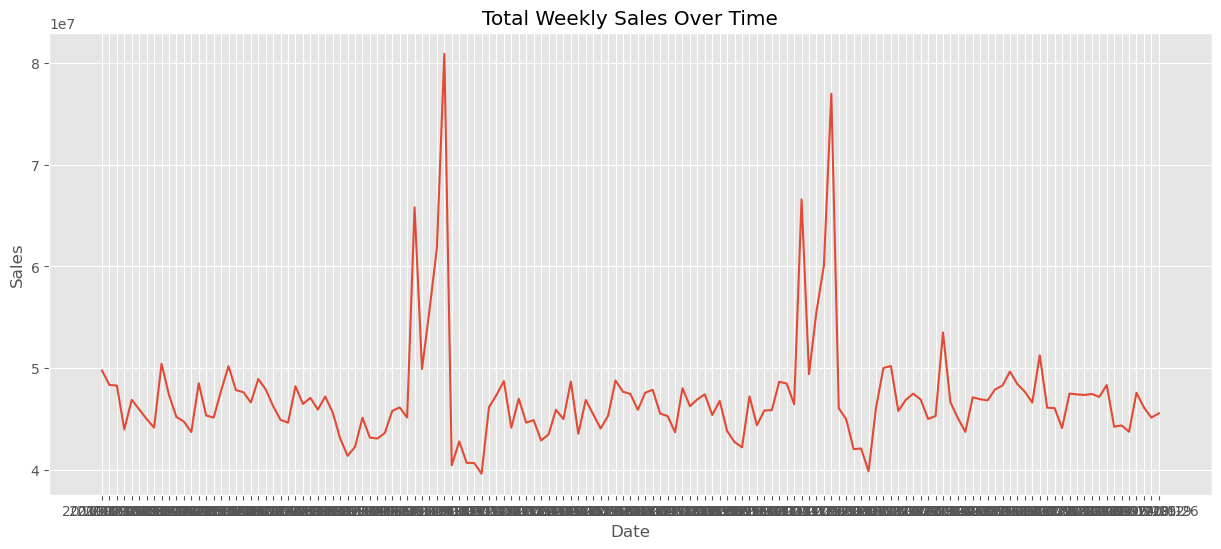

In [5]:
sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))

plt.plot(sales.index, sales.values)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Business Insight
Most weekly sales are concentrated at lower values.

A few stores/departments generate exceptionally high sales (outliers).

## Sales Trend Over Time

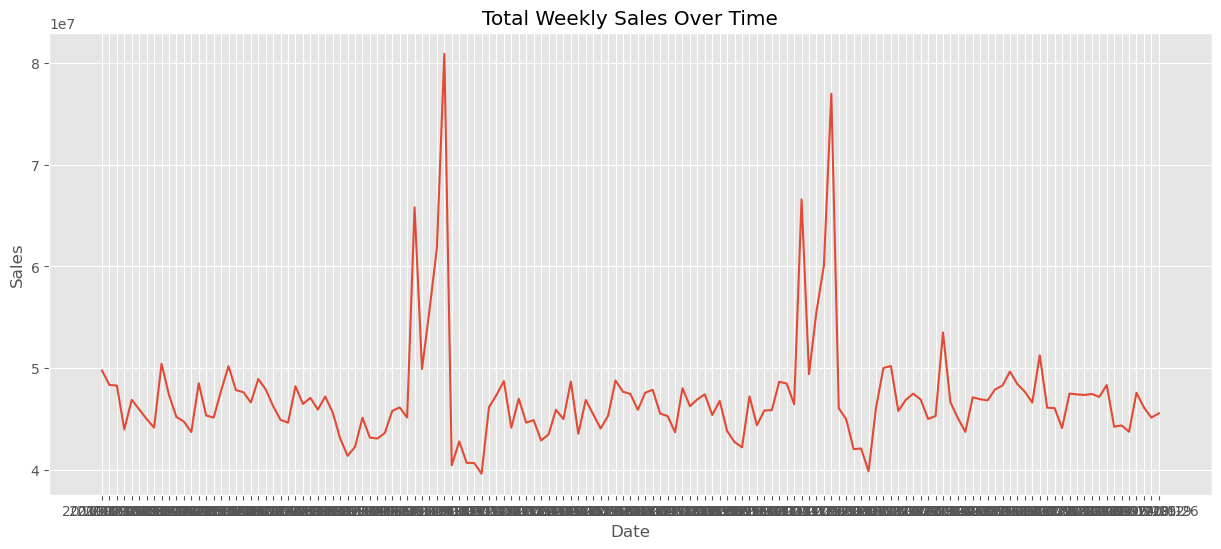

In [9]:
sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))

plt.plot(sales.index, sales.values)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Business Insight
Identify long-term trends.

Spot seasonal peaks and holiday effects.

## Top 10 Stores by Sales

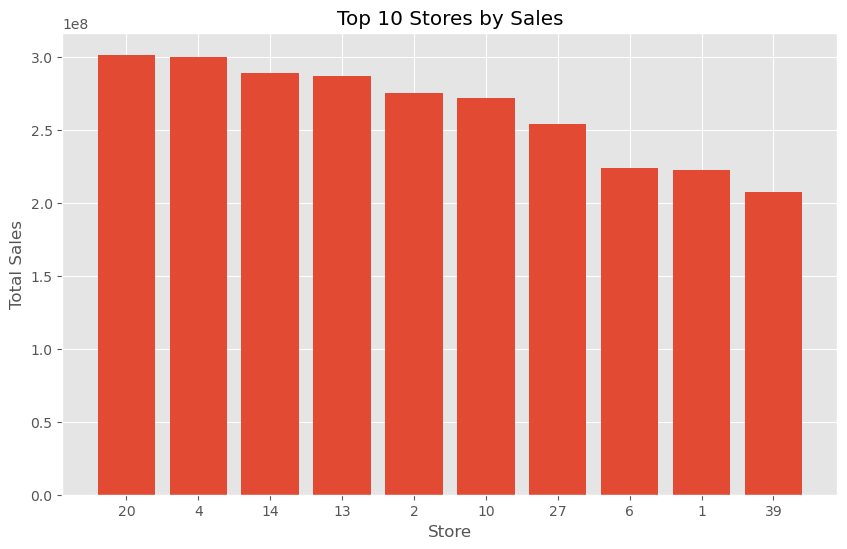

In [6]:
top_store = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(top_store.index.astype(str), top_store.values)

plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

## Store Type Comparison

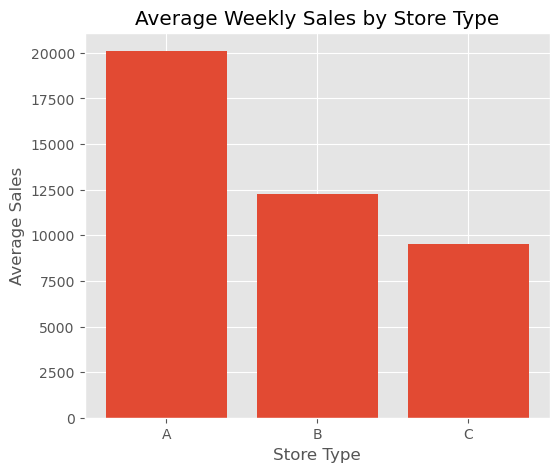

In [7]:
store_type = df.groupby("Type")["Weekly_Sales"].mean()

plt.figure(figsize=(6,5))

plt.bar(store_type.index, store_type.values)

plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

## Holiday vs Non-Holiday Sales

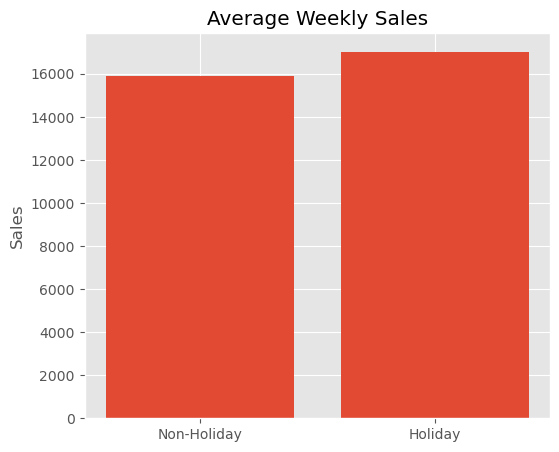

In [8]:
holiday = df.groupby("IsHoliday")["Weekly_Sales"].mean()

plt.figure(figsize=(6,5))

plt.bar(["Non-Holiday", "Holiday"], holiday.values)

plt.title("Average Weekly Sales")
plt.ylabel("Sales")

plt.show()

### Business Insight
Check whether holidays significantly increase sales.

## Correlation Heatmap

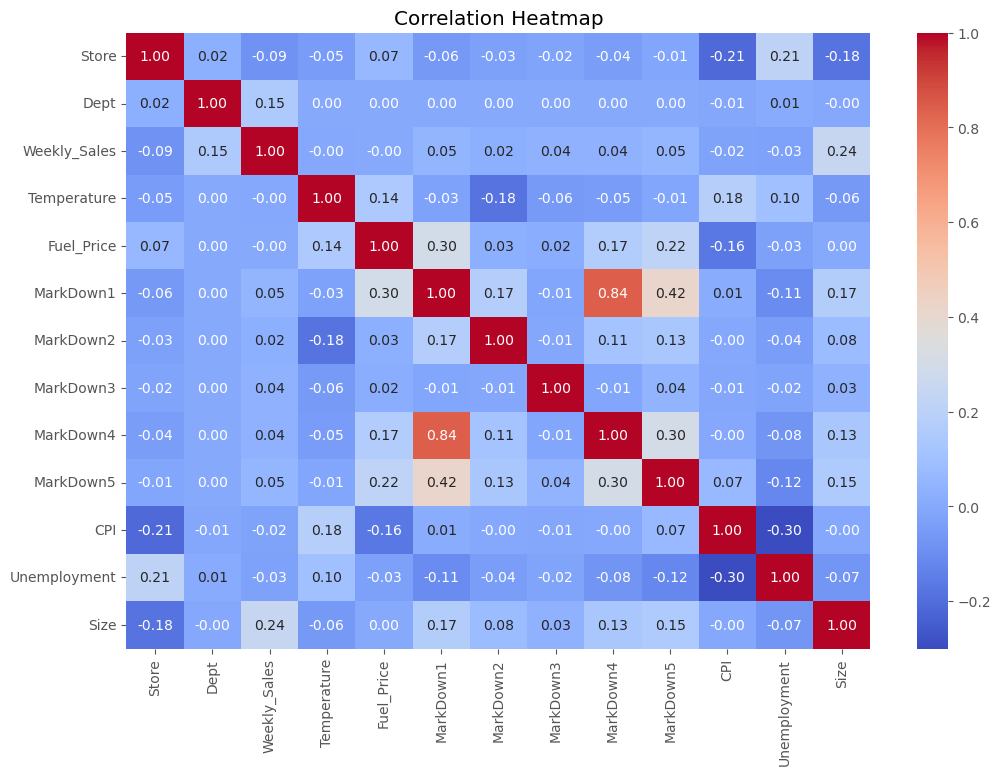

In [10]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight
Identify which variables have stronger relationships with weekly sales.

## Monthly Sales Trend

In [18]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [12]:
df.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Type             object
Size              int64
dtype: object

In [13]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df["Date"].dtype

dtype('<M8[ns]')

In [16]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [17]:
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[ns]
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


In [19]:
monthly_sales = (
    df.groupby("Month")["Weekly_Sales"]
      .sum()
)

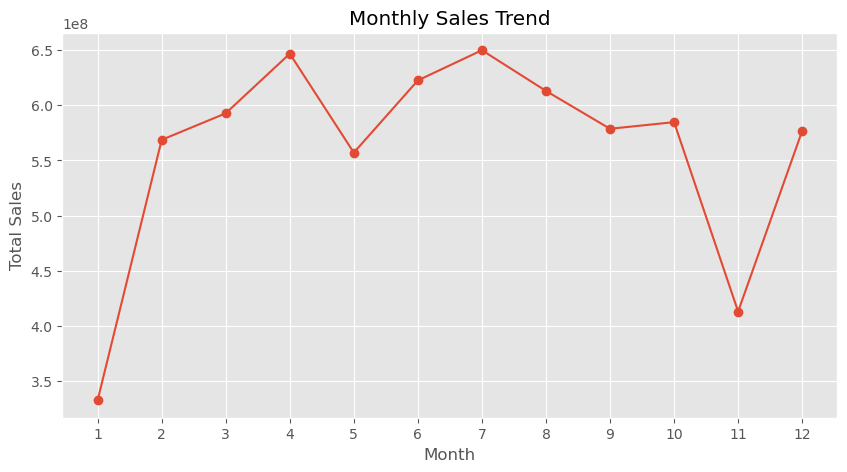

In [20]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1,13))

plt.show()

## Top 10 Departments

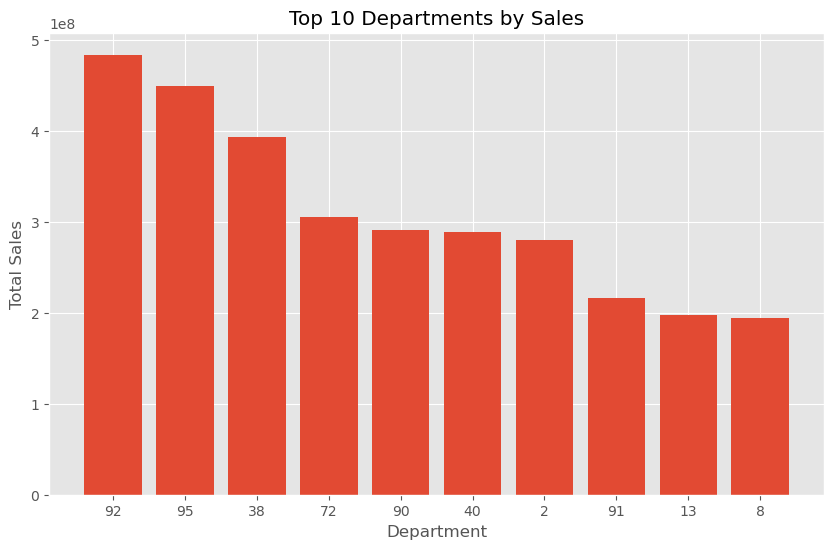

In [21]:
top_dept = (
    df.groupby("Dept")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(top_dept.index.astype(str), top_dept.values)

plt.title("Top 10 Departments by Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.show()

## Store Size vs Sales

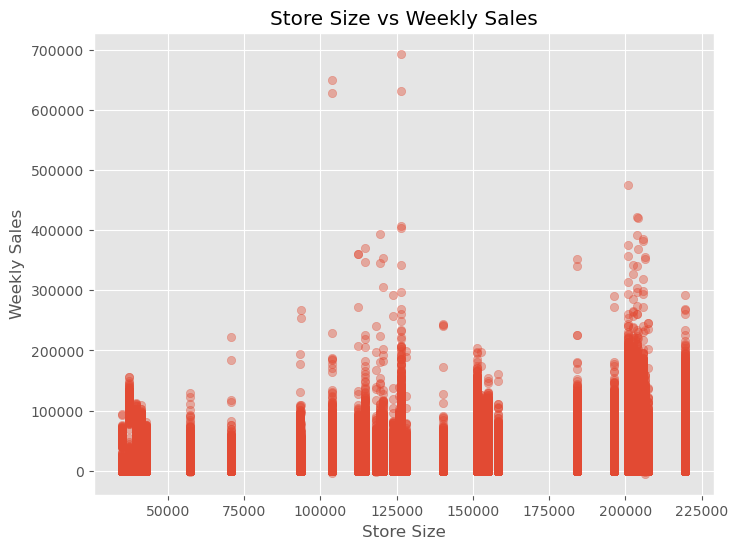

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df["Size"], df["Weekly_Sales"], alpha=0.4)

plt.title("Store Size vs Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")

plt.show()

## Outlier Detection

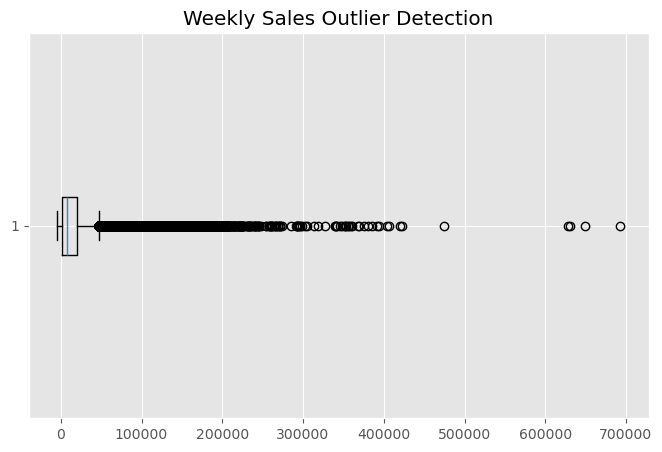

In [23]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Weekly_Sales"], vert=False)

plt.title("Weekly Sales Outlier Detection")

plt.show()

In [25]:
df.to_csv("../data/processed/retail_eda.csv", index=False)